In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [14]:

DATA_PATH = Path('../data/processed/transport_processed.csv')
df = pd.read_csv(DATA_PATH)

X = df.select_dtypes(include=['number', 'bool']).drop(columns=['actual_arrival_delay_min', 'delayed'])
y_reg = df['actual_arrival_delay_min']

test_idx   = np.load('../models/test_idx.npy')
X_test     = X.loc[test_idx]
y_test_reg = y_reg.loc[test_idx]


rfg = joblib.load('../models/rfg_model.pkl')

y_pred = rfg.predict(X_test)

In [15]:
mae  = mean_absolute_error(y_test_reg, y_pred)
rmse = mean_squared_error(y_test_reg, y_pred) ** 0.5

print(f'MAE:  {mae:.2f} min')
print(f'RMSE: {rmse:.2f} min')

MAE:  7.96 min
RMSE: 9.51 min


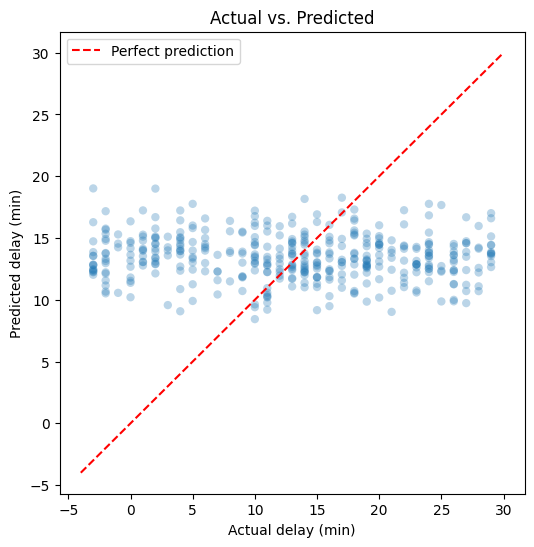

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_reg, y_pred, alpha=0.3, edgecolors='none')

lims = [min(y_test_reg.min(), y_pred.min()) - 1,
        max(y_test_reg.max(), y_pred.max()) + 1]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Actual delay (min)')
ax.set_ylabel('Predicted delay (min)')
ax.set_title('Actual vs. Predicted')
ax.legend()
plt.show()

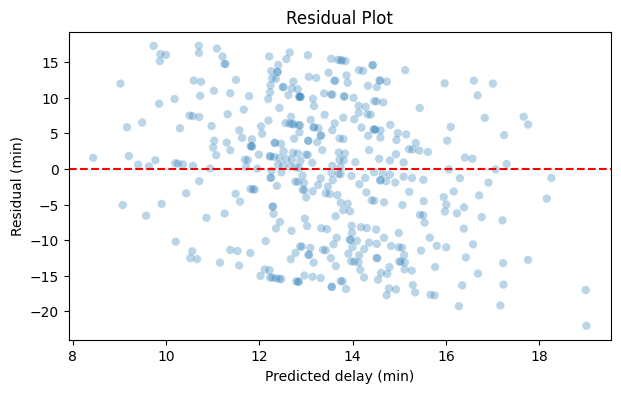

In [17]:
residuals = y_test_reg.values - y_pred

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(y_pred, residuals, alpha=0.3, edgecolors='none')
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Predicted delay (min)')
ax.set_ylabel('Residual (min)')
ax.set_title('Residual Plot')
plt.show()

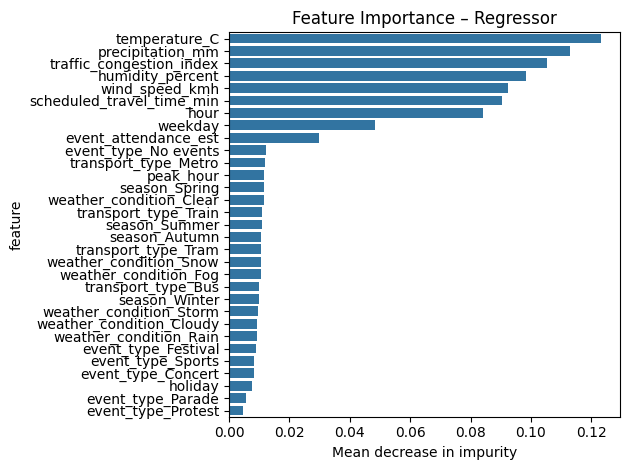

In [18]:
fi_df = (
    pd.DataFrame({'feature': X.columns, 'importance': rfg.feature_importances_})
    .sort_values('importance', ascending=False)
)
sns.barplot(data=fi_df, x='importance', y='feature')
plt.title('Feature Importance – Regressor')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()